# Task 1: Exploratory Analysis and Variable Admissibility

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

train = pd.read_csv('train_group.csv')
train['dteday'] = pd.to_datetime(train['dteday'])

print(train.shape)
train.head(3)

(585, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,292,2011-10-19,4,0,10,0,3,1,3,0.541739,0.513848,0.895217,0.243339,254,2170,2424
1,136,2011-05-16,2,0,5,0,1,1,1,0.577500,0.550512,0.787917,0.126871,773,3185,3958
2,79,2011-03-20,1,0,3,0,0,0,1,0.332500,0.325750,0.473750,0.207721,1047,1424,2471


## 1.1 Variable Admissibility

Before any modelling, we classify each variable by whether it can legitimately serve as a predictor.
The key question for the **prediction setting** is whether the variable is known at forecast time (before any
user counts for that day are observed).

| Variable | Role | Admissibility | Reason |
|---|---|---|---|
| `cnt` | Response |  | Target variable |
| `casual` | Predictor candidate | **Inadmissible** | Component of `cnt`; not observed before day ends |
| `registered` | Predictor candidate | **Inadmissible** | Component of `cnt`; not observed before day ends |
| `instant` | Row index | **Inadmissible** | Arbitrary identifier with no substantive meaning |
| `dteday` | Date | **Inadmissible (raw)** | Encodes the same information as `yr` + `mnth`; using a raw date would cause data leakage on future dates |
| `temp` | Weather | **Clearly admissible** | Daily forecast available before the day |
| `atemp` | Weather | **Admissible with caveat** | Near-duplicate of `temp` (r > 0.99); including both risks collinearity |
| `hum` | Weather | **Clearly admissible** | Daily forecast available |
| `windspeed` | Weather | **Clearly admissible** | Daily forecast available |
| `weathersit` | Weather | **Clearly admissible** | Daily forecast categorical available |
| `season` | Calendar | **Clearly admissible** | Known at scheduling time |
| `yr` | Calendar | **Admissible with caveat** | Captures a linear trend over two years; limited generalisability beyond 2012 |
| `mnth` | Calendar | **Admissible with caveat** | Overlaps heavily with `season`; one of the two is usually sufficient |
| `holiday` | Calendar | **Clearly admissible** | Published in advance |
| `weekday` | Calendar | **Clearly admissible** | Known at scheduling time |
| `workingday` | Calendar | **Admissible with caveat** | Derived from `weekday` and `holiday`; may be redundant if both are included |

**On `casual` and `registered`:** These two variables are not merely correlated with `cnt` -- they sum to it
exactly (`casual + registered = cnt`). Including either as a predictor would be a form of data leakage:
rider counts are not known until after the rental period closes, which is the very quantity we are trying to
predict. They are also mechanically linked to the response rather than causally upstream of it.
Both are inadmissible in any prediction model. For explanatory modelling they could in principle be used
as a decomposition tool, but not as predictors of `cnt`.

**On `dteday`:** The raw date string carries no additional information beyond what `yr`, `mnth`, and `weekday`
already encode. It will not be used as a predictor.

In [ ]:
# Verify: casual + registered = cnt exactly
assert (train['casual'] + train['registered'] == train['cnt']).all(), 'Identity does not hold'
print('casual + registered = cnt holds for all', len(train), 'training rows')

casual + registered = cnt holds for all 585 training rows


## 1.2 Response Variable: Distribution of **cnt**

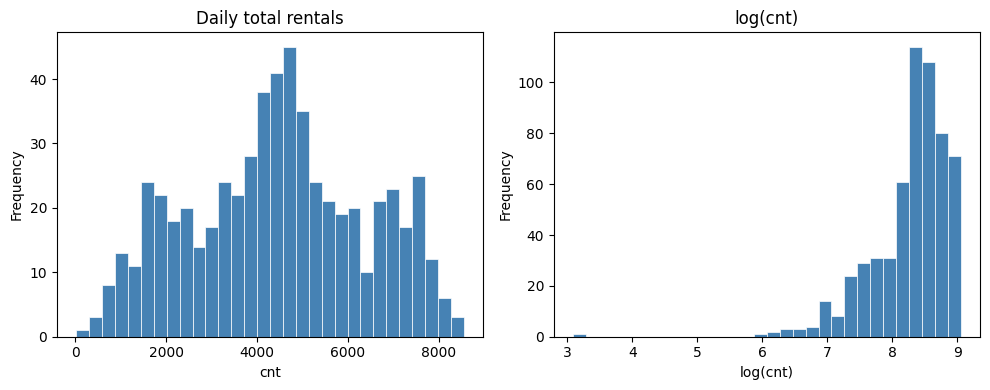

count     585.0
mean     4457.2
std      1936.4
min        22.0
25%      3115.0
50%      4507.0
75%      5847.0
max      8555.0
Name: cnt, dtype: float64
Skewness (cnt):      -0.036
Skewness (log cnt):  -2.049


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(train['cnt'], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('cnt')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Daily total rentals')

axes[1].hist(np.log(train['cnt']), bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('log(cnt)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('log(cnt)')

plt.tight_layout()
plt.savefig('fig_cnt_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(train['cnt'].describe().round(1))
print(f'Skewness (cnt):      {train["cnt"].skew():.3f}')
print(f'Skewness (log cnt):  {np.log(train["cnt"]).skew():.3f}')

`cnt` is approximately bell-shaped with a mild right skew. The distribution is reasonably well-behaved for regression without transformation. `log(cnt)` introduces a left skew and does not improve symmetry here. We will evaluate whether a log transformation is justified more carefully in Task 2, but the raw distribution alone does not strongly motivate it.

## 1.3 Temporal and Calendar Patterns

These plots motivate which calendar variables carry signal and whether there is a year-on-year trend.

C:\Users\Dell\AppData\Local\Temp\ipykernel_23868\1564166078.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='season_label', y='cnt', order=order, palette='Blues', ax=axes[0])
C:\Users\Dell\AppData\Local\Temp\ipykernel_23868\1564166078.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='yr', y='cnt', palette='Blues', ax=axes[2])
C:\Users\Dell\AppData\Local\Temp\ipykernel_23868\1564166078.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['2011', '2012'])


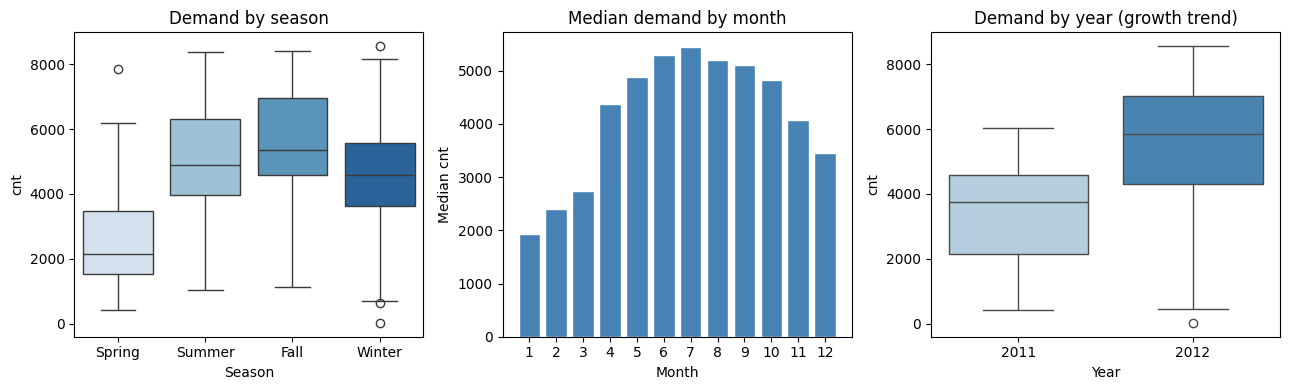

In [ ]:
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
train['season_label'] = train['season'].map(season_labels)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Season
order = ['Spring', 'Summer', 'Fall', 'Winter']
sns.boxplot(data=train, x='season_label', y='cnt', order=order, palette='Blues', ax=axes[0])
axes[0].set_xlabel('Season')
axes[0].set_ylabel('cnt')
axes[0].set_title('Demand by season')

# Month
monthly = train.groupby('mnth')['cnt'].median()
axes[1].bar(monthly.index, monthly.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Median cnt')
axes[1].set_title('Median demand by month')
axes[1].set_xticks(range(1, 13))

# Year
sns.boxplot(data=train, x='yr', y='cnt', palette='Blues', ax=axes[2])
axes[2].set_xticklabels(['2011', '2012'])
axes[2].set_xlabel('Year')
axes[2].set_ylabel('cnt')
axes[2].set_title('Demand by year (growth trend)')

plt.tight_layout()
plt.savefig('fig_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

Demand peaks in summer/fall and troughs in spring and winter, consistent with weather-driven leisure riding.
The month plot refines this: demand builds from March, peaks around June-September, then declines.
There is a clear year-on-year growth from 2011 to 2012, suggesting `yr` captures a business-growth trend
that should be included in models. Because `season` and `mnth` are highly redundant, we will generally
prefer `mnth` for finer granularity, or `season` for parsimony, but not both simultaneously.

C:\Users\Dell\AppData\Local\Temp\ipykernel_23868\1631853153.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='weekday_label', y='cnt', order=order_wd, palette='Blues', ax=axes[0])


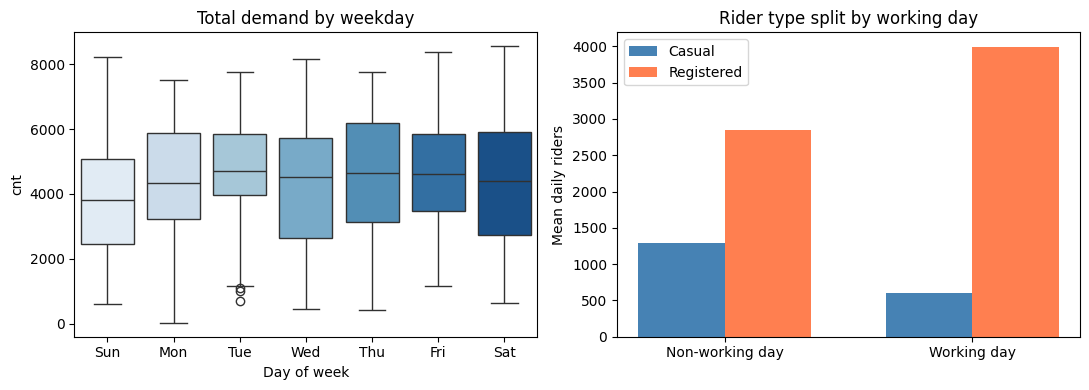

In [ ]:
weekday_labels = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
train['weekday_label'] = train['weekday'].map(weekday_labels)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

order_wd = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
sns.boxplot(data=train, x='weekday_label', y='cnt', order=order_wd, palette='Blues', ax=axes[0])
axes[0].set_xlabel('Day of week')
axes[0].set_ylabel('cnt')
axes[0].set_title('Total demand by weekday')

# Casual vs registered split by workingday
comp = train.groupby('workingday')[['casual', 'registered']].mean().reset_index()
x = np.arange(2)
width = 0.35
axes[1].bar(x - width/2, comp['casual'], width, label='Casual', color='steelblue')
axes[1].bar(x + width/2, comp['registered'], width, label='Registered', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Non-working day', 'Working day'])
axes[1].set_ylabel('Mean daily riders')
axes[1].set_title('Rider type split by working day')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_weekday_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

Total demand is fairly stable across weekdays, but the composition differs sharply: on working days,
registered riders dominate (commuters), while on weekends casual riders make up a larger share.
This pattern motivates the strategic question: the system serves two structurally different demand types.
Even though `casual` and `registered` are inadmissible as predictors, this decomposition informs which
calendar features (workingday, weekday) are important for modelling total demand and understanding its drivers.

## 1.4 Weather Variable Relationships

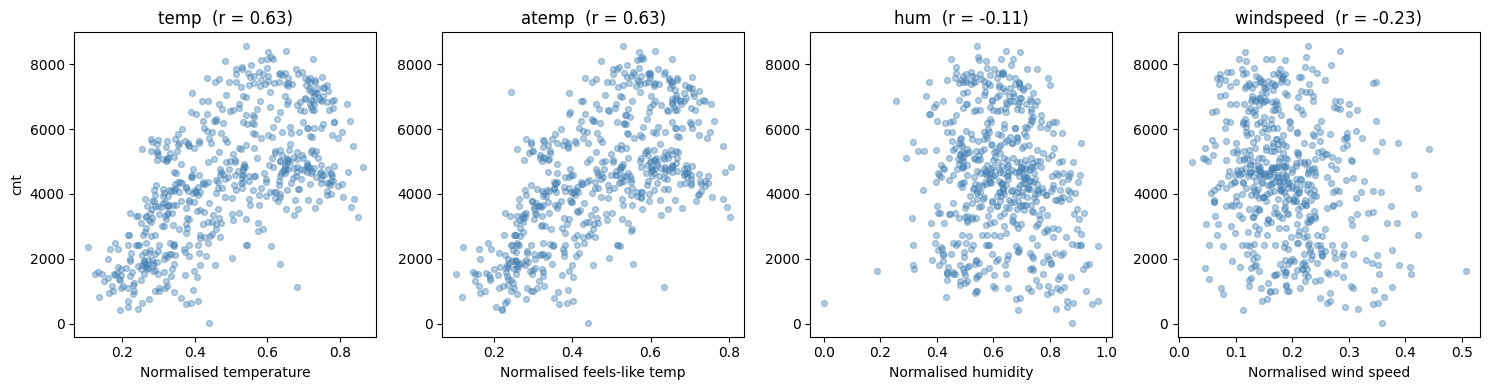

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

weather_vars = ['temp', 'atemp', 'hum', 'windspeed']
labels = ['Normalised temperature', 'Normalised feels-like temp', 'Normalised humidity', 'Normalised wind speed']

for ax, var, lab in zip(axes, weather_vars, labels):
    ax.scatter(train[var], train['cnt'], alpha=0.4, s=18, color='steelblue')
    ax.set_xlabel(lab)
    ax.set_ylabel('cnt' if ax == axes[0] else '')
    r = train[var].corr(train['cnt'])
    ax.set_title(f'{var}  (r = {r:.2f})')

plt.tight_layout()
plt.savefig('fig_weather_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

`temp` and `atemp` show a strong positive association with `cnt` and are nearly identical (see correlation below).
Using both in the same model will cause severe multicollinearity; `temp` is preferred as it is the physically
interpretable measure. Humidity shows a mild negative association. Wind speed has a weak negative association
with noticeable scatter. Neither humidity nor wind speed alone explains much variance, but they may contribute
alongside temperature in a joint model.

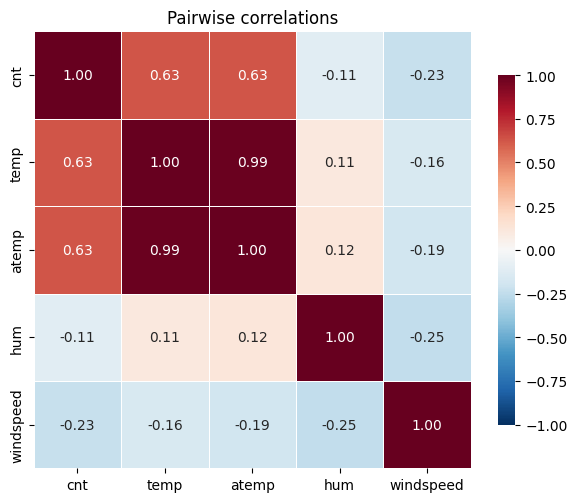

temp vs atemp correlation: 0.9905


In [ ]:
# Correlation among admissible continuous predictors and response
cols = ['cnt', 'temp', 'atemp', 'hum', 'windspeed']
corr = train[cols].corr().round(3)

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Pairwise correlations')
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('temp vs atemp correlation:', train['temp'].corr(train['atemp']).round(4))

## 1.5 Categorical Weather: `weathersit`

C:\Users\Dell\AppData\Local\Temp\ipykernel_23868\1154746710.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='ws_label', y='cnt', order=ws_order_present, palette='Blues', ax=ax)


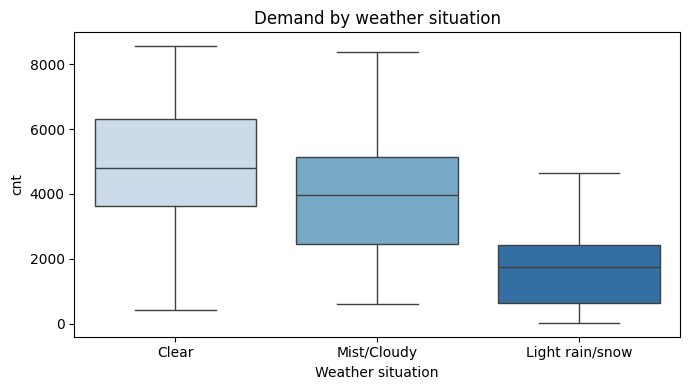

                 median  count
ws_label                      
Clear            4788.5    374
Mist/Cloudy      3959.0    195
Light rain/snow  1751.0     16


In [ ]:
ws_labels = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light rain/snow', 4: 'Heavy rain/snow'}
train['ws_label'] = train['weathersit'].map(ws_labels)

ws_order = ['Clear', 'Mist/Cloudy', 'Light rain/snow', 'Heavy rain/snow']
ws_order_present = [w for w in ws_order if w in train['ws_label'].unique()]

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=train, x='ws_label', y='cnt', order=ws_order_present, palette='Blues', ax=ax)
ax.set_xlabel('Weather situation')
ax.set_ylabel('cnt')
ax.set_title('Demand by weather situation')
plt.tight_layout()
plt.savefig('fig_weathersit.png', dpi=150, bbox_inches='tight')
plt.show()

print(train.groupby('ws_label')['cnt'].agg(['median', 'count']).loc[ws_order_present])

Demand drops monotonically as weather worsens. Clear days have roughly twice the median demand of
light rain/snow days. Category 4 (heavy rain/snow) has very few observations in training data and may
need to be merged with category 3 to avoid unstable coefficient estimates.

## 1.6 Summary: Key Findings for Modelling

The exploratory analysis points to the following:

1. **`casual` and `registered` are inadmissible** as predictors in any model for `cnt`. They are sub-components
   of the response, observed simultaneously with it, and including them is equivalent to predicting the whole
   from its own parts. Their pattern across working days is informative about demand structure but not usable
   as a predictor.

2. **`temp` is the strongest single predictor** (r = 0.63 with cnt). `atemp` is redundant given `temp`
   (r > 0.99 between the two); only one should enter any model.

3. **Seasonal and monthly patterns are strong** and partially mediated by temperature. `season` and `mnth`
   are collinear; for most purposes one suffices. `yr` captures a real growth trend and should be retained.

4. **Working day structure matters** for understanding demand composition, and `workingday` (or `weekday`)
   should be included in explanatory and predictive models.

5. **`log(cnt)` is worth considering** given mild right-skew, and will be evaluated formally in Task 2.

6. The relationship between `temp` and `cnt` is likely confounded by season: warmer temperatures coincide
   with summer, which also brings longer daylight hours and more discretionary time. A simple regression
   of `cnt` on `temp` alone will overstate the causal role of temperature.